In [37]:
##zadanie 1
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import suptitle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42)

n_bootstrap = 1000
accuracies = []

for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_boot, y_boot)

    acc = knn.score(X_test, y_test)
    accuracies.append(acc)


accuracies[:10]


[0.75,
 0.6944444444444444,
 0.7222222222222222,
 0.7222222222222222,
 0.7777777777777778,
 0.7222222222222222,
 0.6944444444444444,
 0.8055555555555556,
 0.6666666666666666,
 0.75]

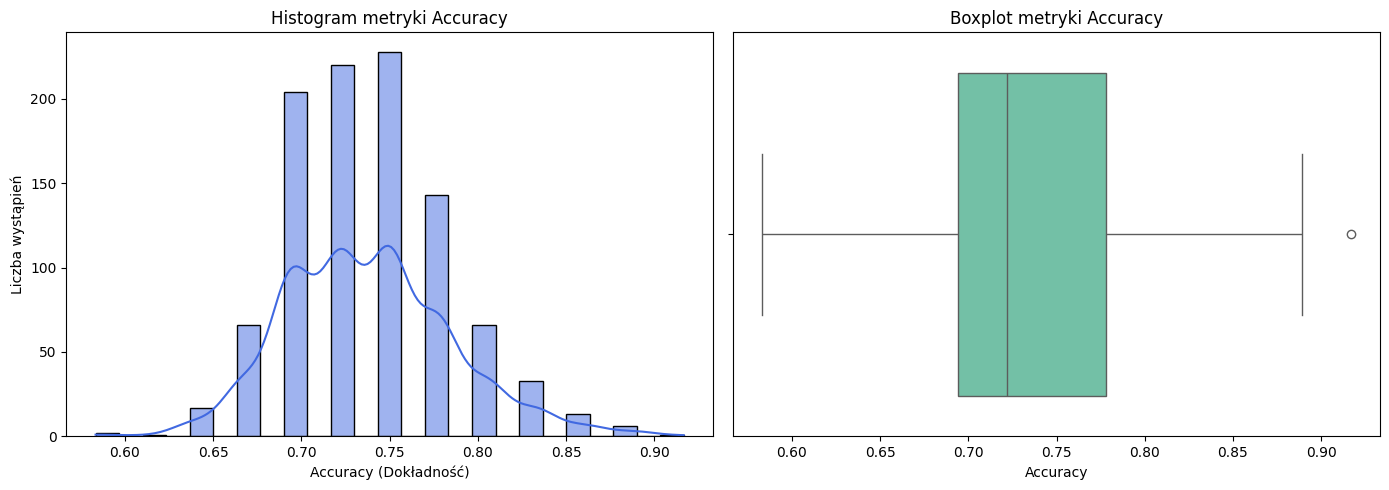

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(accuracies, bins=25, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Histogram metryki Accuracy')
axes[0].set_xlabel('Accuracy (Dokładność)')
axes[0].set_ylabel('Liczba wystąpień')


sns.boxplot(x=accuracies, color='mediumaquamarine', ax=axes[1])
axes[1].set_title('Boxplot metryki Accuracy')
axes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.show()

In [39]:
lower_bound = np.percentile(accuracies, 2.5)
upper_bound = np.percentile(accuracies, 97.5)

print("--- Wyniki Eksperymentu Bootstrapowego ---")
print(f"Średnia dokładność (Accuracy): {np.mean(accuracies):.4f}")
print(f"95% Przedział ufności: od {lower_bound:.4f} do {upper_bound:.4f}")

--- Wyniki Eksperymentu Bootstrapowego ---
Średnia dokładność (Accuracy): 0.7375
95% Przedział ufności: od 0.6667 do 0.8333


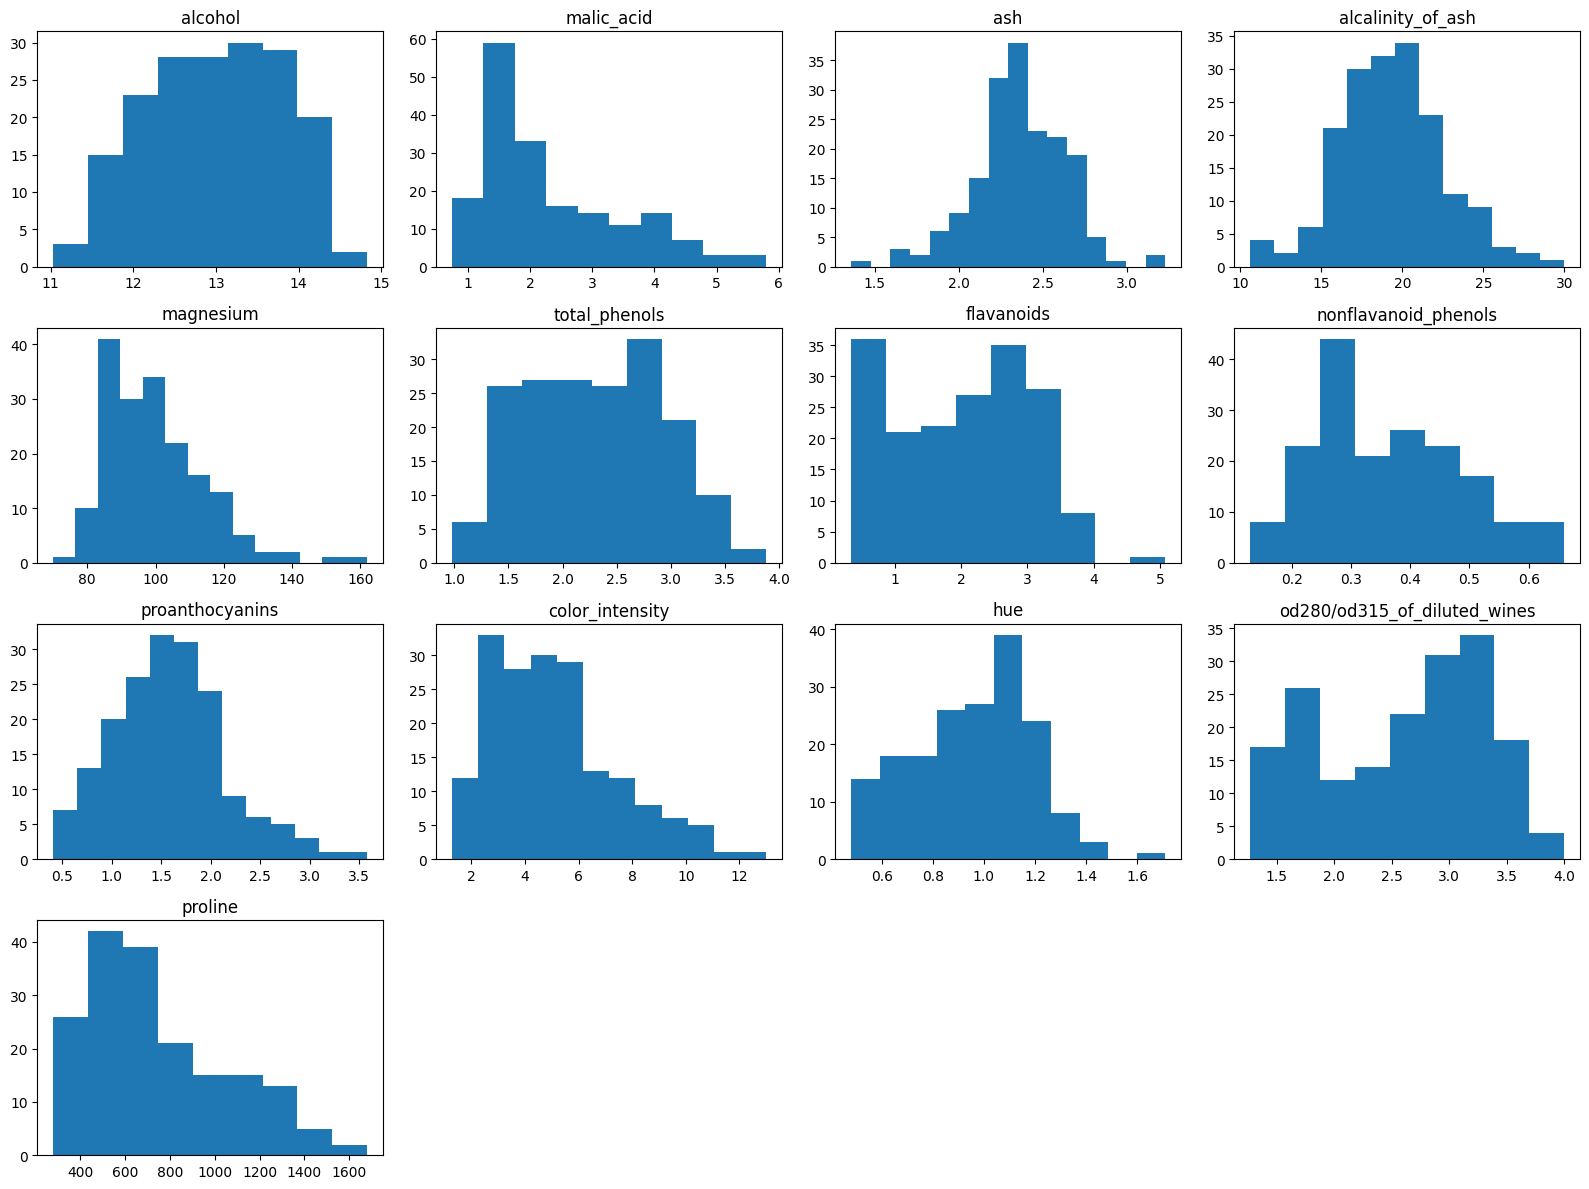

In [45]:
##zadanie 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

X = data.data


fig, axes = plt.subplots(4,4, figsize=(16,12))
axes = axes.flatten()

for i in range(len(data.feature_names)):
    axes[i].hist(X[:, i], bins='auto')
    axes[i].set_title(data.feature_names[i])

for i in range(len(data.feature_names), len(axes)):
    fig.delaxes(axes[i])


plt.tight_layout()
plt.show()